In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("Tata Motors Sales.xlsx")

In [3]:
df.head(10)

,sales_id,year,region,country,units_sold,average_sale_price,dealer_discount_pct,customer_rating,sales_channel,color,payment_mode,is_first_time_buyer,feedback_score,insurance_included,discount_reason,salesperson_id,customer_age,customer_gender,customer_income_group
0,1,2022,East,Germany,971,41294.96,7.33,1.5,Direct,White,Cash,False,7.82,True,Clearance,371,53,Male,High
1,2,2016,Northeast,India,1568,26594.21,0.75,3.3,Direct,Red,Lease,False,2.68,True,New Model Launch,179,73,Female,Low
2,3,2018,West,UK,870,22886.68,10.17,2.7,Fleet,Silver,Cash,True,4.19,False,New Model Launch,208,58,Female,High
3,4,2016,North,Germany,2563,32067.28,7.69,2.5,Fleet,Silver,Cash,True,8.65,False,No Discount,639,61,Male,Medium
4,5,2019,West,Australia,685,69292.54,18.83,1.9,Fleet,Silver,Cash,True,2.67,False,No Discount,739,44,Male,Medium
5,6,2023,North,Australia,1779,37534.03,4.79,4.1,Direct,Black,Cash,True,5.06,True,Festival,522,74,Male,Low
6,7,2015,Northeast,Australia,663,58655.39,9.26,3.7,Online,Silver,Cash,False,1.75,True,Festival,52,23,Female,Low
7,8,2019,East,Germany,1294,25439.48,4.49,2.5,Fleet,Grey,Loan,True,7.93,True,No Discount,567,42,Female,Low
8,9,2023,East,USA,2019,52250.40,9.96,3.8,Fleet,Red,Lease,True,2.14,True,No Discount,309,20,Female,Low
9,10,2015,East,France,2717,50117.64,2.92,2.9,Dealership,Blue,Loan,True,8.01,True,New Model Launch,331,23,Female,Low


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   sales_id               250000 non-null  int64  
 1   year                   250000 non-null  int64  
 2   region                 250000 non-null  object 
 3   country                250000 non-null  object 
 4   units_sold             250000 non-null  int64  
 5   average_sale_price     250000 non-null  float64
 6   dealer_discount_pct    250000 non-null  float64
 7   customer_rating        250000 non-null  float64
 8   sales_channel          250000 non-null  object 
 9   color                  250000 non-null  object 
 10  payment_mode           250000 non-null  object 
 11  is_first_time_buyer    250000 non-null  bool   
 12  feedback_score         250000 non-null  float64
 13  insurance_included     250000 non-null  bool   
 14  discount_reason        250000 non-nu

In [5]:
df.shape

(250000, 19)

In [7]:
df.describe(include="object")

,region,country,sales_channel,color,payment_mode,discount_reason,customer_gender,customer_income_group
count,250000,250000,250000,250000,250000,250000,250000,250000
unique,6,7,4,6,3,4,3,3
top,East,Germany,Fleet,Silver,Cash,New Model Launch,Male,High
freq,41898,35910,62520,41775,83732,63042,83467,83489


In [8]:
df.isnull().sum()

sales_id                 0
year                     0
region                   0
country                  0
units_sold               0
average_sale_price       0
dealer_discount_pct      0
customer_rating          0
sales_channel            0
color                    0
payment_mode             0
is_first_time_buyer      0
feedback_score           0
insurance_included       0
discount_reason          0
salesperson_id           0
customer_age             0
customer_gender          0
customer_income_group    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.groupby("year")["units_sold"].sum()

year
2015    37339963
2016    37912908
2017    37324956
2018    37576253
2019    37849255
2020    37633865
2021    37599158
2022    37224307
2023    37477554
2024    37575987
Name: units_sold, dtype: int64

In [11]:
df.groupby("country")["units_sold"].sum().sort_values(ascending=False)

country
Germany      54122190
UK           53814209
France       53599018
Australia    53587503
India        53574500
USA          53466599
Japan        53350187
Name: units_sold, dtype: int64

In [12]:
df.groupby("region")["units_sold"].sum().sort_values(ascending=False)

region
South        62858814
Central      62824495
East         62693390
Northeast    62648733
North        62286455
West         62202319
Name: units_sold, dtype: int64

In [13]:
df["Revenue"] = df["units_sold"] * df["average_sale_price"]

In [14]:
df.head(5)

,sales_id,year,region,country,units_sold,average_sale_price,dealer_discount_pct,customer_rating,sales_channel,color,payment_mode,is_first_time_buyer,feedback_score,insurance_included,discount_reason,salesperson_id,customer_age,customer_gender,customer_income_group,Revenue
0,1,2022,East,Germany,971,41294.96,7.33,1.5,Direct,White,Cash,False,7.82,True,Clearance,371,53,Male,High,40097406.16
1,2,2016,Northeast,India,1568,26594.21,0.75,3.3,Direct,Red,Lease,False,2.68,True,New Model Launch,179,73,Female,Low,41699721.28
2,3,2018,West,UK,870,22886.68,10.17,2.7,Fleet,Silver,Cash,True,4.19,False,New Model Launch,208,58,Female,High,19911411.60
3,4,2016,North,Germany,2563,32067.28,7.69,2.5,Fleet,Silver,Cash,True,8.65,False,No Discount,639,61,Male,Medium,82188438.64
4,5,2019,West,Australia,685,69292.54,18.83,1.9,Fleet,Silver,Cash,True,2.67,False,No Discount,739,44,Male,Medium,47465389.90


In [15]:
col = df.pop("Revenue")
df.insert(6, "Revenue", col)

In [16]:
df.head(5)

,sales_id,year,region,country,units_sold,average_sale_price,Revenue,dealer_discount_pct,customer_rating,sales_channel,color,payment_mode,is_first_time_buyer,feedback_score,insurance_included,discount_reason,salesperson_id,customer_age,customer_gender,customer_income_group
0,1,2022,East,Germany,971,41294.96,40097406.16,7.33,1.5,Direct,White,Cash,False,7.82,True,Clearance,371,53,Male,High
1,2,2016,Northeast,India,1568,26594.21,41699721.28,0.75,3.3,Direct,Red,Lease,False,2.68,True,New Model Launch,179,73,Female,Low
2,3,2018,West,UK,870,22886.68,19911411.60,10.17,2.7,Fleet,Silver,Cash,True,4.19,False,New Model Launch,208,58,Female,High
3,4,2016,North,Germany,2563,32067.28,82188438.64,7.69,2.5,Fleet,Silver,Cash,True,8.65,False,No Discount,639,61,Male,Medium
4,5,2019,West,Australia,685,69292.54,47465389.90,18.83,1.9,Fleet,Silver,Cash,True,2.67,False,No Discount,739,44,Male,Medium


In [22]:
df.columns = df.columns.str.lower()

In [23]:
df.head(5)

,sales_id,year,region,country,units_sold,average_sale_price,revenue,dealer_discount_pct,customer_rating,sales_channel,color,payment_mode,is_first_time_buyer,feedback_score,insurance_included,discount_reason,salesperson_id,customer_age,customer_gender,customer_income_group
0,1,2022,east,germany,971,41294.96,40097406.16,7.33,1.5,direct,white,cash,False,7.82,True,clearance,371,53,male,high
1,2,2016,northeast,india,1568,26594.21,41699721.28,0.75,3.3,direct,red,lease,False,2.68,True,new model launch,179,73,female,low
2,3,2018,west,uk,870,22886.68,19911411.60,10.17,2.7,fleet,silver,cash,True,4.19,False,new model launch,208,58,female,high
3,4,2016,north,germany,2563,32067.28,82188438.64,7.69,2.5,fleet,silver,cash,True,8.65,False,no discount,639,61,male,medium
4,5,2019,west,australia,685,69292.54,47465389.90,18.83,1.9,fleet,silver,cash,True,2.67,False,no discount,739,44,male,medium


In [25]:
df.groupby("country")["revenue"].sum().sort_values(ascending=False)

country
germany      2.026071e+12
uk           2.025712e+12
india        2.018366e+12
usa          2.011416e+12
australia    2.008316e+12
france       2.001405e+12
japan        1.986477e+12
Name: revenue, dtype: float64

In [26]:
df["customer_rating"].mean()

np.float64(3.2479647999999997)

In [28]:
df.groupby("sales_channel")["revenue"].sum()

sales_channel
dealership    3.511402e+12
direct        3.508445e+12
fleet         3.519725e+12
online        3.538192e+12
Name: revenue, dtype: float64

In [30]:
df.groupby("payment_mode")["revenue"].sum()

payment_mode
cash     4.719638e+12
lease    4.660514e+12
loan     4.697612e+12
Name: revenue, dtype: float64

In [31]:
df["customer_age"].describe()

count    250000.000000
mean         45.924608
std          16.430489
min          18.000000
25%          32.000000
50%          46.000000
75%          60.000000
max          74.000000
Name: customer_age, dtype: float64

In [32]:
df.groupby("customer_gender")["revenue"].sum()

customer_gender
female    4.672032e+12
male      4.698405e+12
other     4.707327e+12
Name: revenue, dtype: float64

In [33]:
df.groupby("customer_income_group")["revenue"].sum()

customer_income_group
high      4.709931e+12
low       4.690199e+12
medium    4.677634e+12
Name: revenue, dtype: float64

In [34]:
df.groupby("discount_reason")["dealer_discount_pct"].mean()

discount_reason
clearance           9.983884
festival            9.987673
new model launch    9.985466
no discount         9.987563
Name: dealer_discount_pct, dtype: float64

In [35]:
df.groupby("is_first_time_buyer")["revenue"].sum()

is_first_time_buyer
False    7.029451e+12
True     7.048313e+12
Name: revenue, dtype: float64

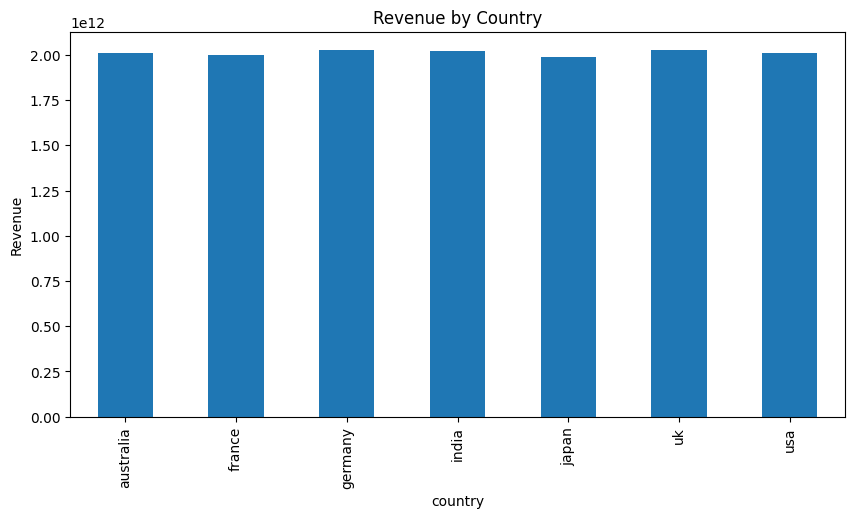

In [36]:
import matplotlib.pyplot as plt

df.groupby("country")["revenue"].sum().plot(kind="bar", figsize=(10,5))
plt.title("Revenue by Country")
plt.ylabel("Revenue")
plt.show()

In [37]:
df.head(10)

,sales_id,year,region,country,units_sold,average_sale_price,revenue,dealer_discount_pct,customer_rating,sales_channel,color,payment_mode,is_first_time_buyer,feedback_score,insurance_included,discount_reason,salesperson_id,customer_age,customer_gender,customer_income_group
0,1,2022,east,germany,971,41294.96,4.009741e+07,7.33,1.5,direct,white,cash,False,7.82,True,clearance,371,53,male,high
1,2,2016,northeast,india,1568,26594.21,4.169972e+07,0.75,3.3,direct,red,lease,False,2.68,True,new model launch,179,73,female,low
2,3,2018,west,uk,870,22886.68,1.991141e+07,10.17,2.7,fleet,silver,cash,True,4.19,False,new model launch,208,58,female,high
3,4,2016,north,germany,2563,32067.28,8.218844e+07,7.69,2.5,fleet,silver,cash,True,8.65,False,no discount,639,61,male,medium
4,5,2019,west,australia,685,69292.54,4.746539e+07,18.83,1.9,fleet,silver,cash,True,2.67,False,no discount,739,44,male,medium
5,6,2023,north,australia,1779,37534.03,6.677304e+07,4.79,4.1,direct,black,cash,True,5.06,True,festival,522,74,male,low
6,7,2015,northeast,australia,663,58655.39,3.888852e+07,9.26,3.7,online,silver,cash,False,1.75,True,festival,52,23,female,low
7,8,2019,east,germany,1294,25439.48,3.291869e+07,4.49,2.5,fleet,grey,loan,True,7.93,True,no discount,567,42,female,low
8,9,2023,east,usa,2019,52250.40,1.054936e+08,9.96,3.8,fleet,red,lease,True,2.14,True,no discount,309,20,female,low
9,10,2015,east,france,2717,50117.64,1.361696e+08,2.92,2.9,dealership,blue,loan,True,8.01,True,new model launch,331,23,female,low


In [39]:
sales_channel_revenue = df.groupby("sales_channel")["revenue"].sum()

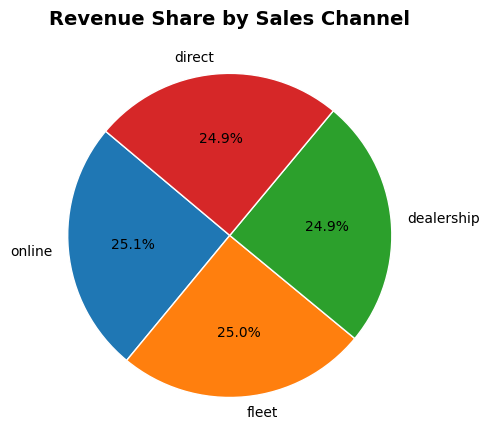

In [42]:
import matplotlib.pyplot as plt

sales_channel_revenue = (
    df.groupby("sales_channel")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(5,5))

plt.pie(
    sales_channel_revenue,
    labels=sales_channel_revenue.index,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor":"white"}
)

plt.title("Revenue Share by Sales Channel", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

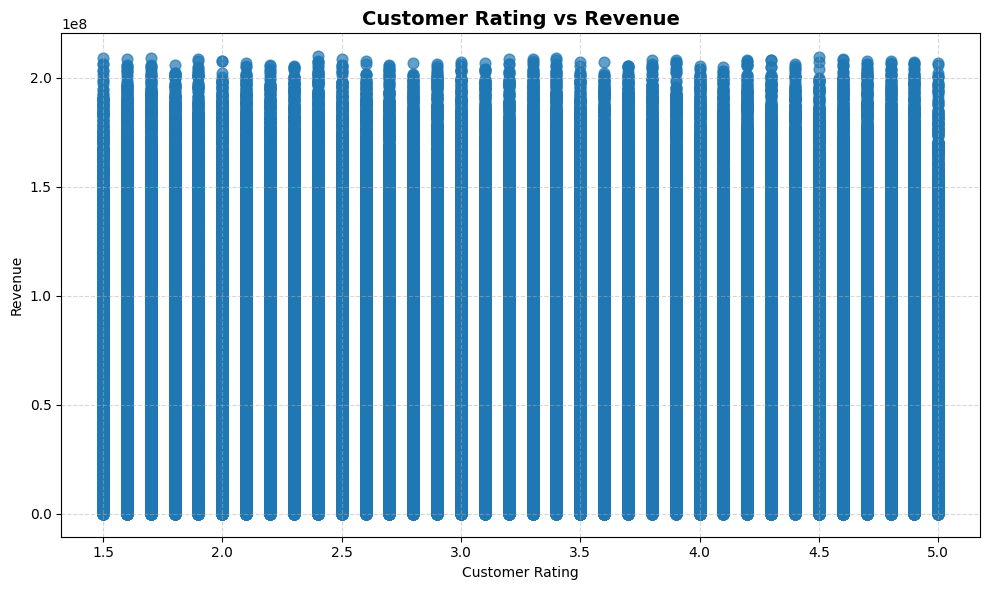

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df["customer_rating"],
    df["revenue"],
    alpha=0.7,
    s=60
)

plt.title("Customer Rating vs Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Customer Rating")
plt.ylabel("Revenue")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
from sqlalchemy import create_engine


# Step 1: Read sheet
df = pd.read_excel("Tata Motors Sales.xlsx")

# MySQL Connection
username = "root"
password = "tushar21"
host = "localhost"
port = "3306"
database = "tatamotors_db"

engine = create_engine(
    f"mysql+mysqlconnector://{username}:{password}@{host}:{port}/{database}"
)

# Upload DataFrame
df.to_sql(
    name="tata_motors_sales",
    con=engine,
    if_exists="replace",
    index=False
)

print("✅ Data uploaded successfully!")

✅ Data uploaded successfully!
